# CANDOR Corpus

This notebook runs the same OCEAN personality-prediction analysis we built for the WASSA 2024
shared task (`tutorials/wassa2024/`), but on the **CANDOR corpus**.
* [Science Advances paper](https://www.science.org/doi/10.1126/sciadv.adf3197)

## Introduction

CANDOR is a large corpus of **1,656 recorded two-person video conversations** (~1,456 unique
participants, ~530k turns). Each participant filled out **personality (Big Five / OCEAN)**,
demographic, and other psychometric surveys, then had an unstructured ~25-minute conversation
with a stranger. Every conversation was transcribed and turn-segmented.

Here we predict each speaker's **self-reported OCEAN** traits from their side of the
conversation, mirroring the WASSA PER track. Two mechanisms are compared: an **LLM
summary-mem** pipeline (`prediction.py`, built on `src/summary_mem/`) and a **DLATK**
n-gram / embedding ridge-regression baseline (`train_model.py`).

### Data

CANDOR already lives in the local MySQL/MariaDB database **`candor`**, so — unlike the WASSA
tutorial, which reshapes raw CSVs — there is no data-prep step. Everything reads the tables
directly, under their own column names:

| Table | Columns used |
|---|---|
| `msgsc` | `conversation_id`, `speaker`, `turn_id`, `message`, `message_id` |
| `surveys` | `user_id`, `conversation_id`, `sex`, `race`, `edu`, `age`, `my_*` |

### Targets

Self-reported OCEAN (`surveys.my_open`, `my_conscientious`, `my_extraversion`, `my_agreeable`,
`my_neurotic`; ~1–5 scale). Note CANDOR reports **neuroticism** directly, unlike WASSA's
reverse-scored "stability". A participant is surveyed once *per conversation*, so someone with
several conversations carries several slightly different OCEAN vectors.

### Evaluation

Scored with the **Pearson product-moment correlation** between predicted and self-reported
trait, averaged over traits.

In [1]:
from pathlib import Path
import pandas as pd
import plotnine as p9
from sqlalchemy import create_engine

DATABASE = "candor"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

## Read data

Straight from the `candor` database, under the tables' own column names — `msgsc` for the
turns, `surveys` for the per-participant self-reports.

In [2]:
engine = create_engine(f"mysql://ssubrahmanya@localhost/{DATABASE}?charset=utf8mb4")

# the conversation turns
query = "SELECT conversation_id, speaker, turn_id, message_id FROM msgsc"
conversations = pd.read_sql(query, engine)

# the surveys — one row per participant per conversation
surveys = pd.read_sql("SELECT * FROM surveys", engine)

## Descriptives

Computed from the prepared tables — number of conversations and participants, participant
demographics, self-reported OCEAN distributions, and turns per conversation.

In [3]:
print(f"conversations: {surveys['conversation_id'].nunique()}")
print(f"participants: {surveys['user_id'].nunique()}")

conversations \
    .groupby("conversation_id") \
    .agg({"turn_id": "count"}) \
    .rename(columns={"turn_id": "Turns per conversation"}) \
    .describe() \
    .round(2)

conversations: 1656
participants: 1456


,Turns per conversation
count,1656.00
mean,320.24
std,92.41
min,9.00
25%,261.00
50%,309.00
75%,359.00
max,966.00


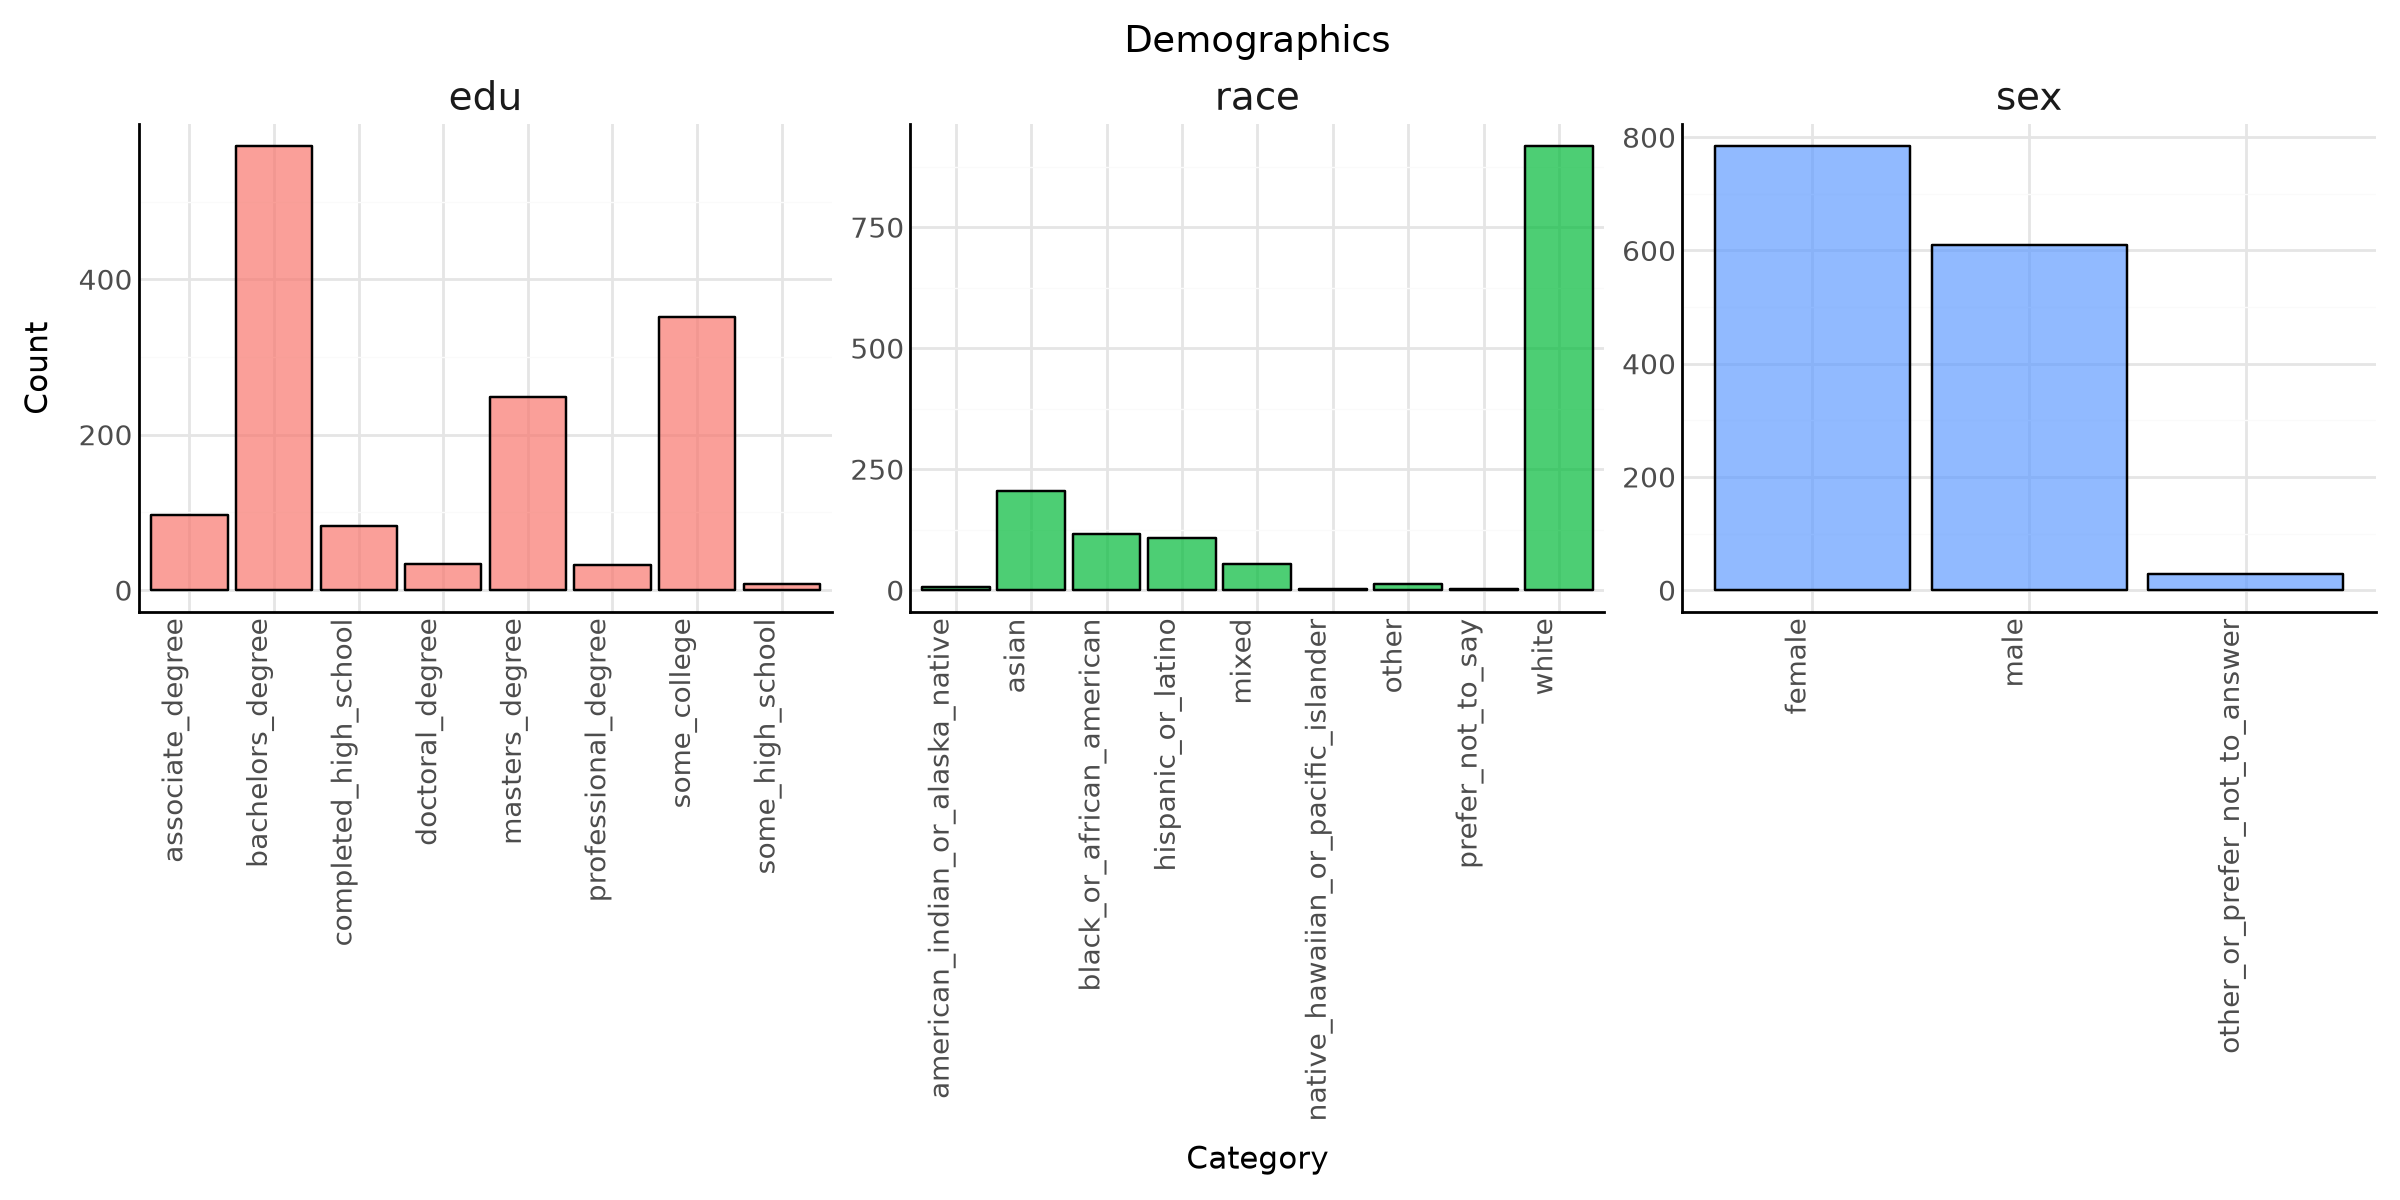

In [4]:
# Demographic distributions — categorical survey fields (one row per participant).
categorical = surveys.drop_duplicates("user_id")[["sex", "race", "edu"]].dropna()
categorical = categorical.melt(var_name="variable", value_name="value")

(
    p9.ggplot(categorical, p9.aes(x="value", fill="variable")) +
    p9.geom_bar(color="black", alpha=0.7) +
    p9.facet_wrap("variable", scales="free", ncol=3) +
    p9.labs(
        title="Demographics",
        x="Category",
        y="Count",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(12, 6),
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=10),
        axis_text_x= p9.element_text(rotation=90, ha="right"),
        strip_text= p9.element_text(size=14),
        legend_position="none"
    )
)

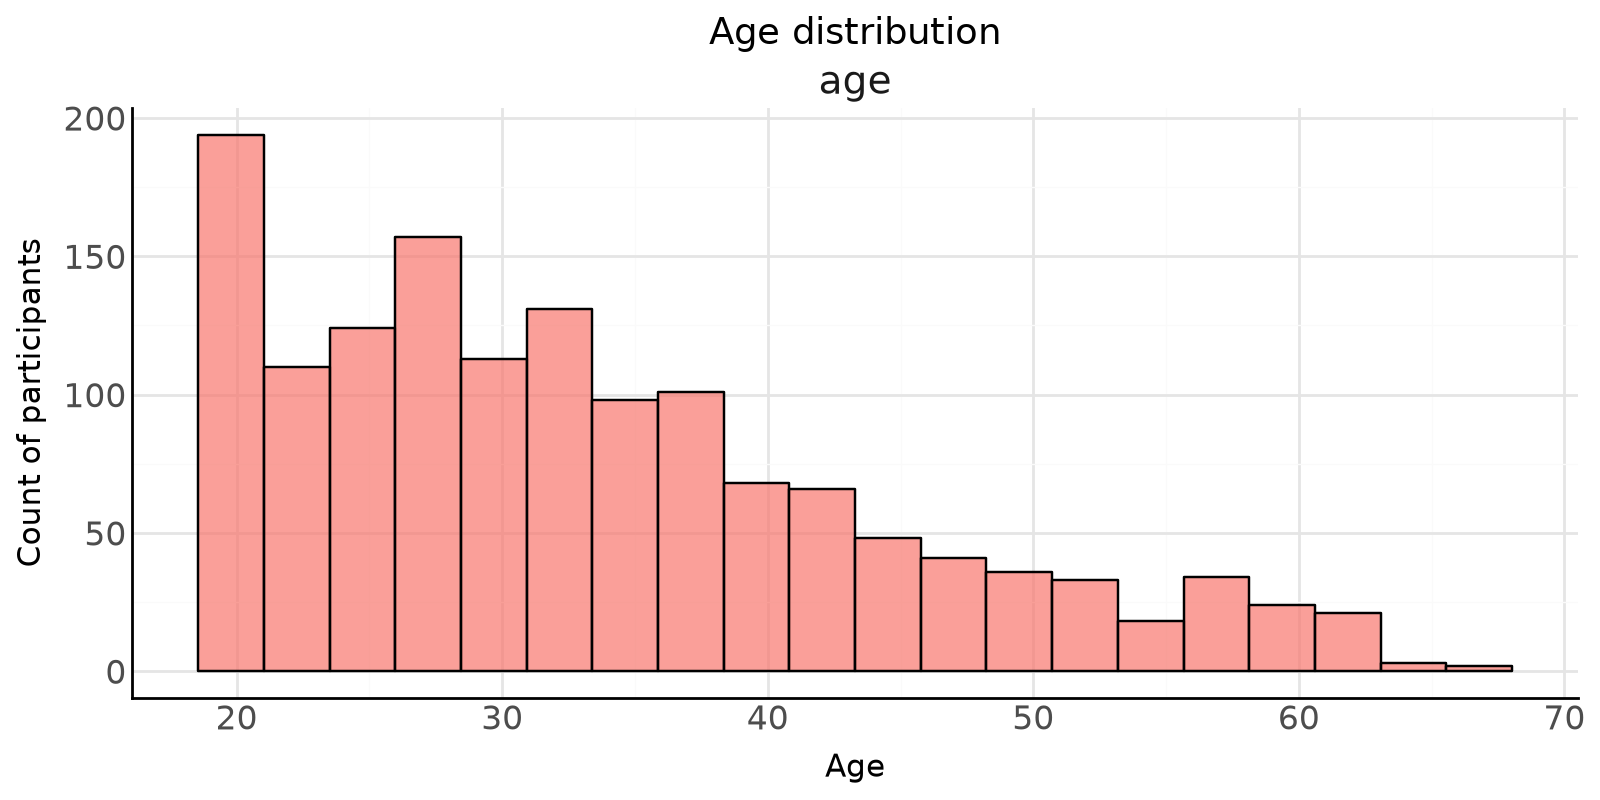

In [5]:
# Age distribution (one row per participant). CANDOR has no income field.
numerical = surveys.drop_duplicates("user_id")[["age"]].dropna()
numerical = numerical.melt(var_name="variable", value_name="value")

(
    p9.ggplot(numerical, p9.aes(x="value", fill="variable")) +
    p9.geom_histogram(bins=20, color="black", alpha=0.7) +
    p9.facet_wrap("variable", scales="free", ncol=2) +
    p9.labs(
        title="Age distribution",
        x="Age",
        y="Count of participants",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(8, 4),
        legend_position="none",
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
    )
)

,count,mean,std,min,25%,50%,75%,max
my_open,1422.0,4.02,0.77,1.0,3.67,4.00,4.67,5.0
my_conscientious,1422.0,3.41,0.96,1.0,2.67,3.33,4.33,5.0
my_extraversion,1422.0,3.14,0.95,1.0,2.33,3.00,4.00,5.0
my_agreeable,1422.0,3.90,0.77,1.0,3.33,4.00,4.33,5.0
my_neurotic,1422.0,2.93,1.10,1.0,2.00,3.00,3.67,5.0


/data/summary-mem/.venv/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 170 rows containing non-finite values.


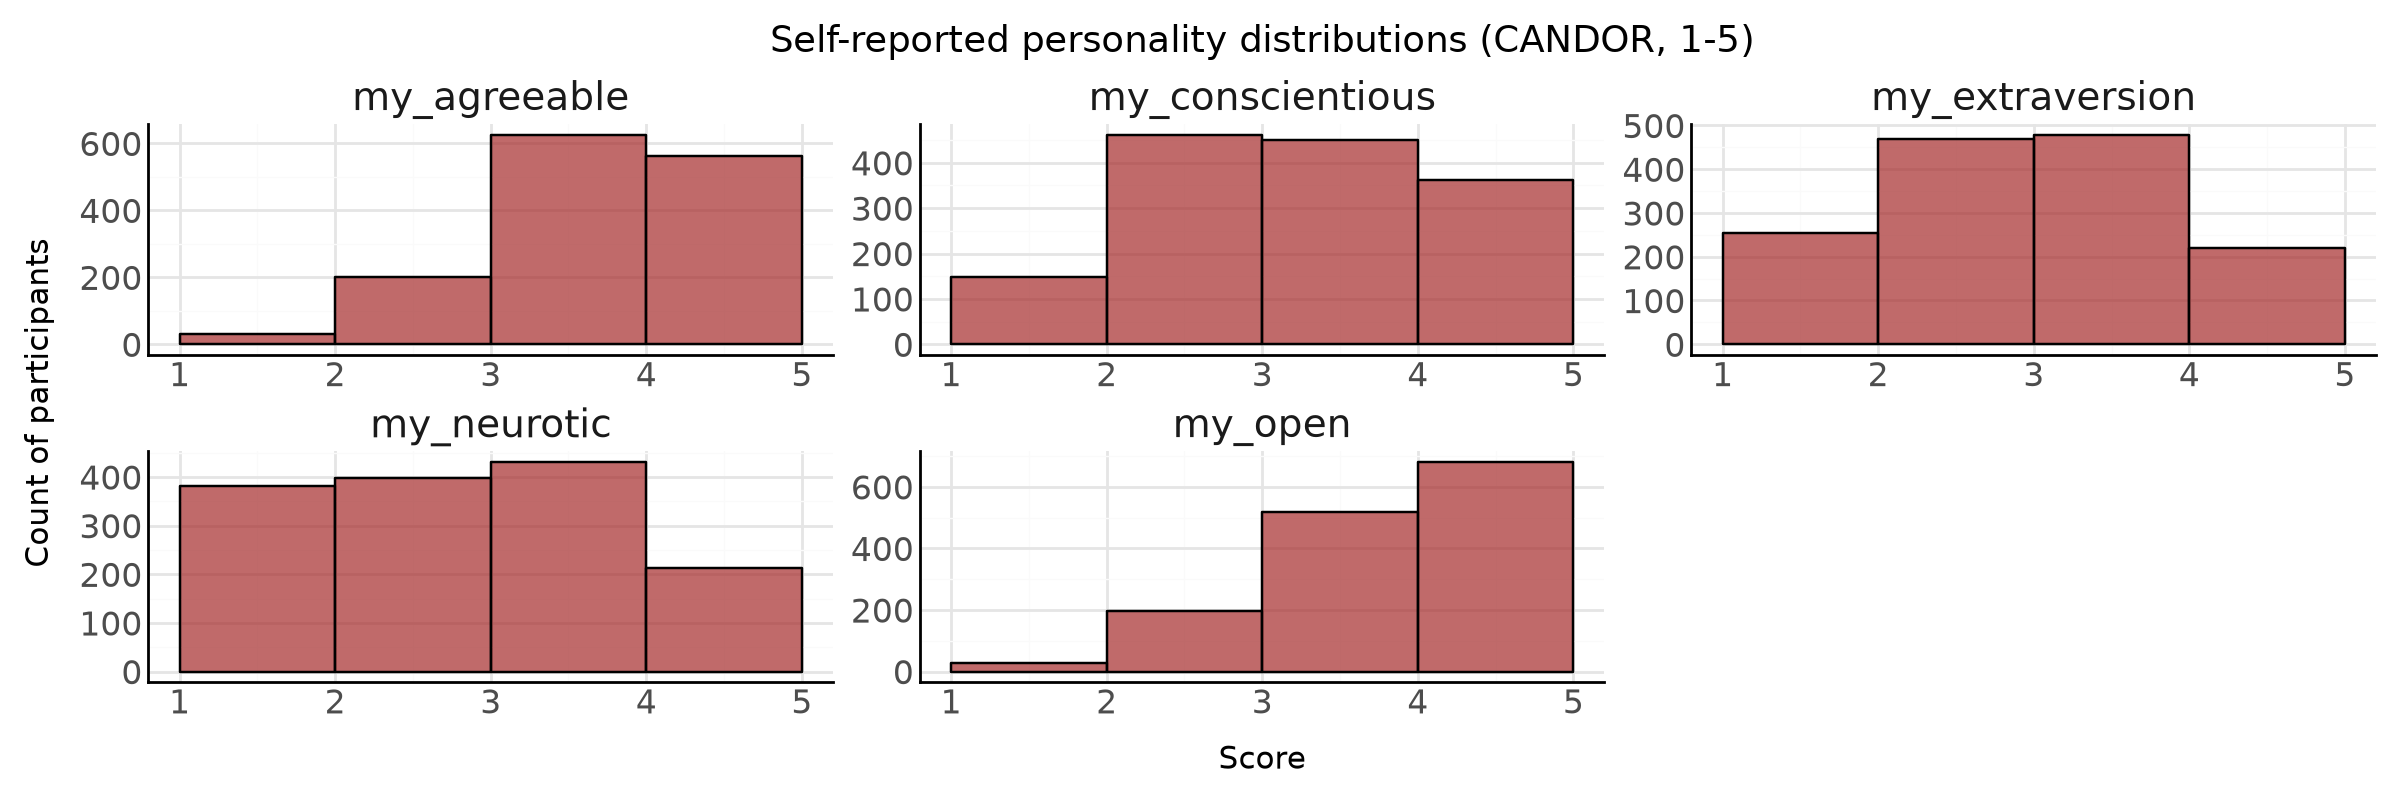

In [6]:
# CANDOR's self-reported OCEAN, on a ~1-5 scale. Neuroticism is reported directly.
traits = [
    "my_open", 
    "my_conscientious", 
    "my_extraversion", 
    "my_agreeable", 
    "my_neurotic"
]
personality = surveys.drop_duplicates("user_id")[traits]

display(personality.describe().round(2).T)

personality = personality.melt(var_name="trait", value_name="score")
(
    p9.ggplot(personality, p9.aes(x="score")) +
    p9.geom_histogram(breaks=range(1, 6), fill="brown", color="black", alpha=0.7) +
    p9.facet_wrap("trait", scales="free", ncol=3) +
    p9.scale_x_continuous(breaks=range(1, 6)) +
    p9.labs(
        title="Self-reported personality distributions (CANDOR, 1-5)",
        x="Score",
        y="Count of participants",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(12, 4),
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
    )
)

## Experiments

Run the `prediction.py` script with appropriate flags and obtain the prediction CSVs with the corresponding metrics.

#### LLM predicted personality

In [ ]:
import pandas as pd
import plotnine as p9

def plot_distributions(df: pd.DataFrame, traits: list[str], title: str):

    plot = (
        p9.ggplot(
            data=df, 
            mapping=p9.aes(
                x="factor(score)", 
                fill="source", 
                color="source"
            )
        ) +
        p9.geom_bar(
            alpha=0.4, 
            position=p9.position_dodge(preserve="single")
        ) +
        p9.facet_wrap("trait", scales="free", ncol=3) +
        p9.labs(
            title=title,
            x="Score",
            y="Count",
            fill="",
            color="",
        ) +
        p9.theme_minimal() +
        p9.theme(
            figure_size=(12, 6),
            axis_line= p9.element_line(color="black"),
            axis_text= p9.element_text(size=12),
            strip_text= p9.element_text(size=14),
            legend_position="bottom",
        )
    )

    return plot

In [ ]:
from scipy.stats import pearsonr

# source = "summary"
source = "in_context"

# prediction.py names its columns pred_<trait> after the survey column it targets.
predictions = pd.read_csv(f"predictions_{source}.csv")
predictions = predictions.rename(columns={f"pred_{t}": f"predicted_{t}" for t in TRAITS})
predictions = predictions[["conversation_id", "speaker"] + [f"predicted_{t}" for t in TRAITS]]

# Ground truth from the surveys table, keyed (conversation_id, user_id).
ground_truth = surveys[["conversation_id", "user_id"] + TRAITS]
ground_truth = ground_truth.rename(columns={t: f"gt_{t}" for t in TRAITS})

comparison = pd.merge(
    predictions,
    ground_truth,
    left_on=["conversation_id", "speaker"],
    right_on=["conversation_id", "user_id"],
    how="left"
)

rows = []
for trait in TRAITS:
    pair = comparison[[f"predicted_{trait}", f"gt_{trait}"]].dropna()
    r, p = pearsonr(pair[f"predicted_{trait}"], pair[f"gt_{trait}"])
    rows.append(
        {
            "trait": trait,
            "n": len(pair),
            "pearson_r": r,
            "p_value": p,
        }
    )

correlations = pd.DataFrame(rows)
display(correlations.round(3))

comparison = comparison.melt(
    id_vars=["conversation_id", "speaker"],
    value_vars=[f"predicted_{t}" for t in TRAITS] + [f"gt_{t}" for t in TRAITS],
    var_name="trait",
    value_name="score"
)

# 'predicted_my_open' / 'gt_my_open' -> source 'predicted'|'gt', trait 'my_open'
comparison[["source", "trait"]] = comparison["trait"].str.split("_", n=1, expand=True)
# CANDOR self-reports are fractional 1-5 means, so bucket to the nearest integer for the bars.
comparison["score"] = comparison["score"].round().astype("Int64")

plot_distributions(
    comparison, 
    TRAITS, 
    title="Predicted vs. Ground Truth Personality Distributions"
)

#### OpenPersonality model

In [6]:
import pandas as pd
from scipy.stats import pearsonr
from sqlalchemy import create_engine

group_field = "speaker"  # the unit of prediction, one row per person
engine = create_engine(f"mysql://ssubrahmanya@localhost/candor?charset=utf8mb4")

# Language-based OCEAN, one row per (group_id, trait), ridge output in `group_norm`.
query = f"SELECT * FROM `feat$p_ridg_ocean$msgsc${group_field}`"
language = pd.read_sql(query, engine)
language[group_field] = language["group_id"]

language = (
    language
        .pivot(
            index=group_field, 
            columns="feat", 
            values="group_norm"
        )
        .reset_index()
)

# CANDOR surveys a person once per conversation, so average their OCEAN into one vector.
traits = [
    "my_open", 
    "my_conscientious", 
    "my_extraversion", 
    "my_agreeable", 
    "my_neurotic"
]
surveys = pd.read_sql("SELECT * FROM surveys", engine)
outcomes = (
    surveys[["user_id"] + traits]
    .groupby("user_id")
    .mean()
    .reset_index()
)

comparison = pd.merge(
    language, 
    outcomes, 
    left_on=group_field, 
    right_on="user_id", 
    how="inner"
)

# neu_z is neuroticism and CANDOR reports neuroticism directly (unlike WASSA's reverse-scored
# "stability"), so a model that works gives a *positive* r on that row.
traits = {
    "ope_z": "my_open",
    "con_z": "my_conscientious",
    "ext_z": "my_extraversion",
    "agr_z": "my_agreeable",
    "neu_z": "my_neurotic",
}

rows = []
for feat, outcome in traits.items():
    pair = comparison[[feat, outcome]].dropna()
    r, p = pearsonr(pair[feat], pair[outcome])
    rows.append(
        {
            "trait": feat, 
            "outcome": outcome, 
            "n_people": len(pair), 
            "pearson_r": r, 
            "p_value": p
        }
    )

pd.DataFrame(rows).round(3)

,trait,outcome,n_people,pearson_r,p_value
0,ope_z,my_open,1431,0.156,0.0
1,con_z,my_conscientious,1431,0.119,0.0
2,ext_z,my_extraversion,1431,0.193,0.0
3,agr_z,my_agreeable,1431,0.126,0.0
4,neu_z,my_neurotic,1431,0.204,0.0


/home/ssubrahmanya/summary-mem/.venv/lib/python3.12/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 125 rows containing missing values.


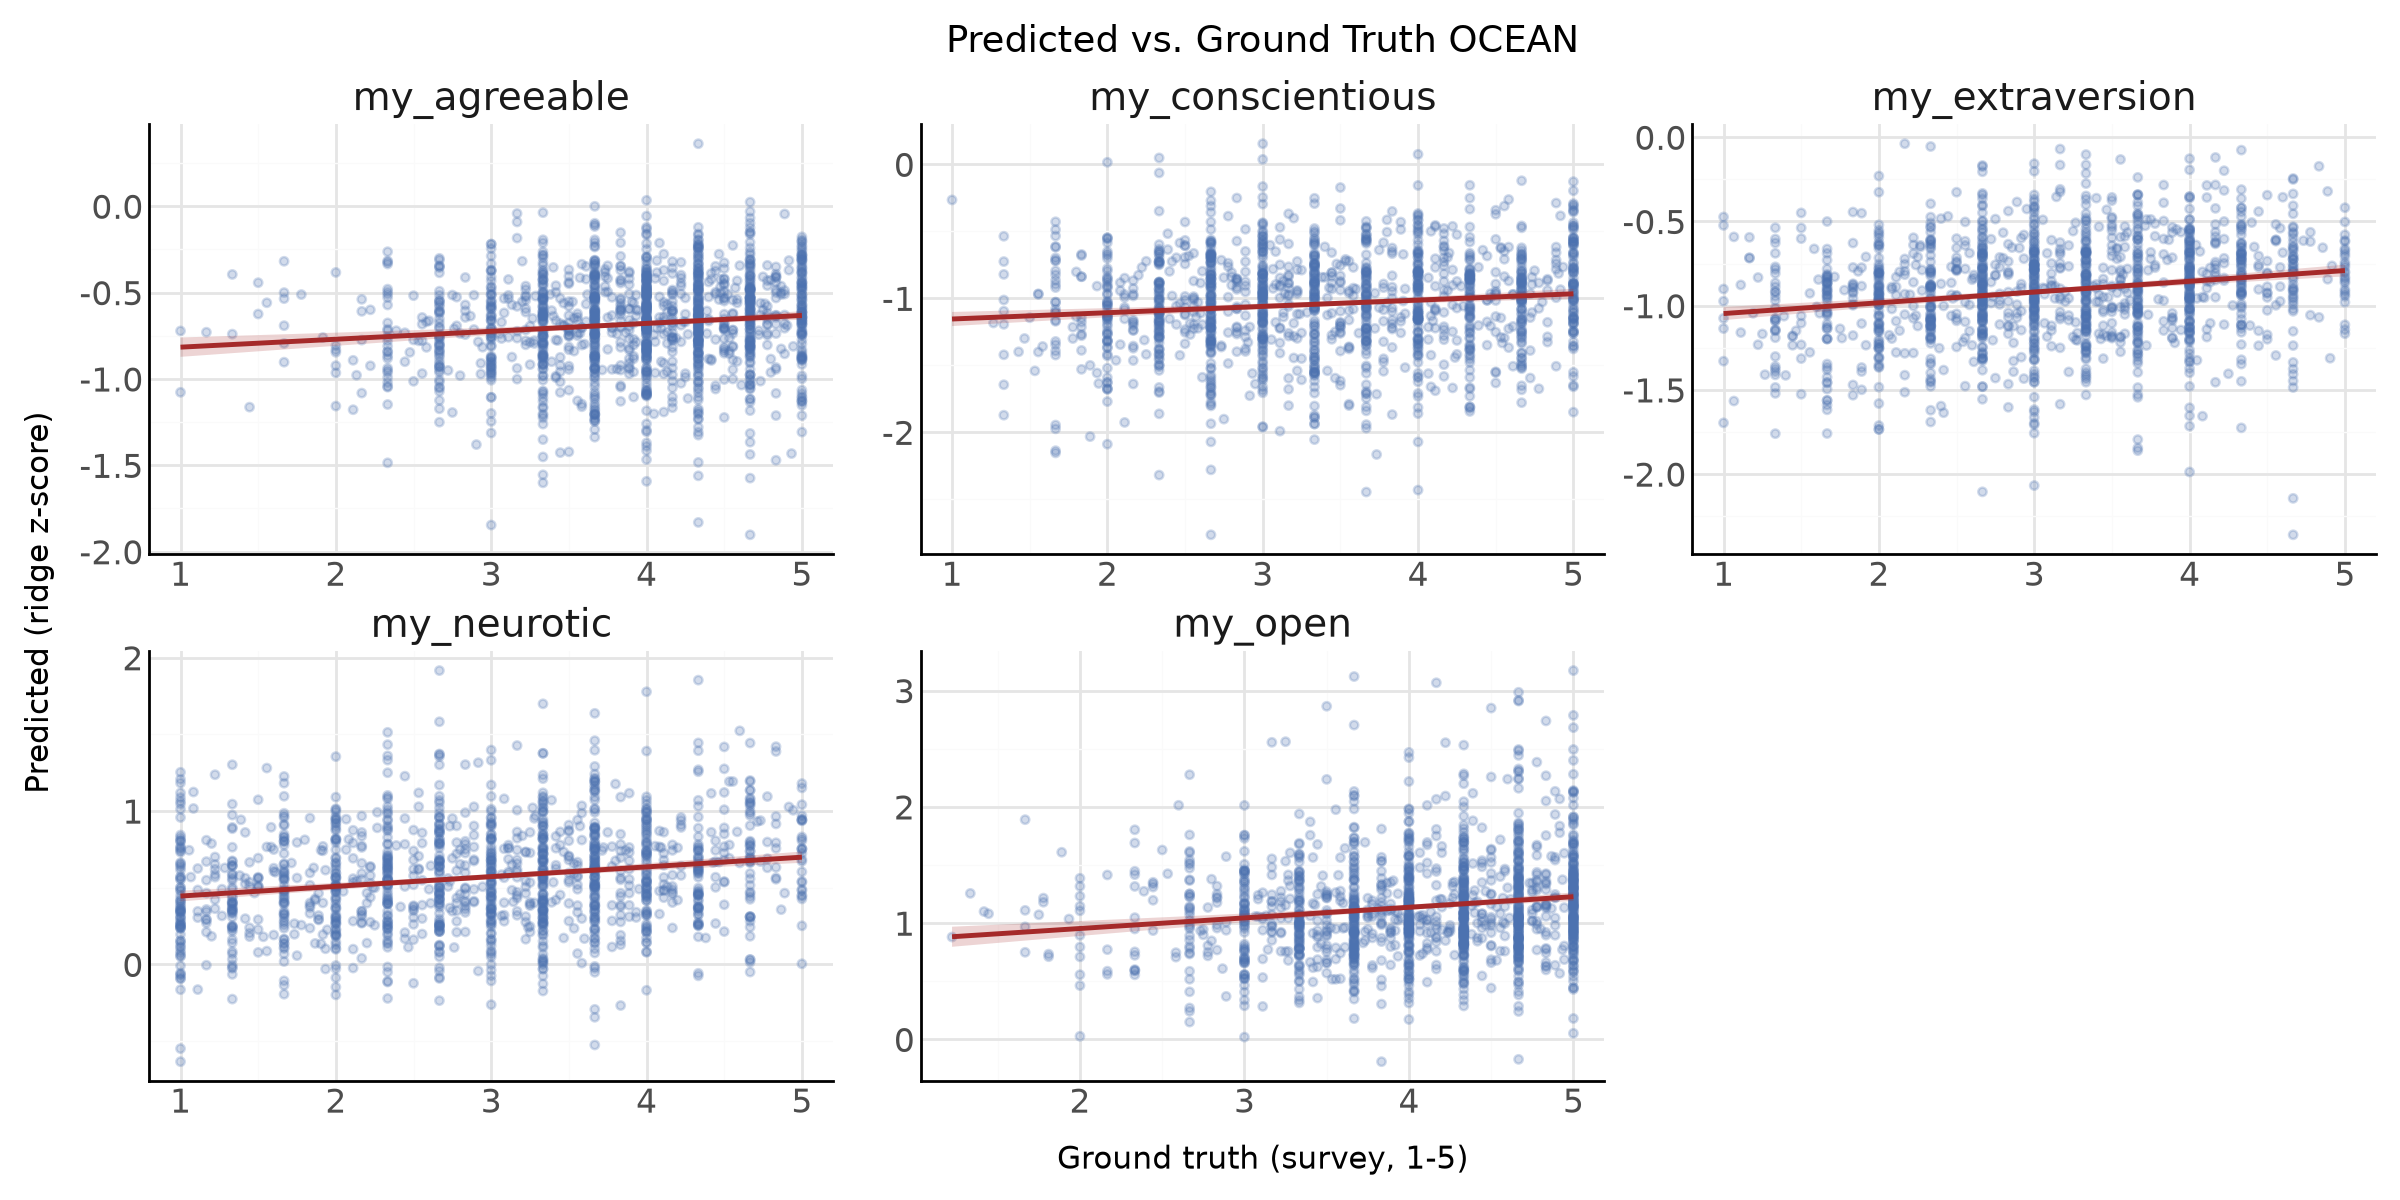

In [7]:
import plotnine as p9

comparison = comparison.melt(
    id_vars=[group_field], 
    value_vars=list(traits.keys()) + list(traits.values()), 
    var_name="trait", 
    value_name="score"
)

comparison["source"] = comparison["trait"].map(lambda t: "predicted" if t in traits.keys() else "ground_truth")
comparison["trait"] = comparison["trait"].map(lambda t: traits[t] if t in traits else t)

comparison = (
    comparison
    .pivot_table(
        index=[group_field, "trait"], 
        columns="source", 
        values="score"
    )
    .reset_index()
)

(
    p9.ggplot(
        data=comparison,
        mapping=p9.aes(x="ground_truth", y="predicted")) +
    p9.geom_point(alpha=0.25, size=1.2, color="#4C72B0") +
    p9.geom_smooth(method="lm", color="brown", fill="brown", alpha=0.2) +
    p9.facet_wrap("trait", scales="free", ncol=3) +
    p9.labs(
        title=f"Predicted vs. Ground Truth OCEAN",
        x="Ground truth (survey, 1-5)",
        y="Predicted (ridge z-score)",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(12, 6),
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
    )
)

In [ ]:
import pickle

import numpy as np
import pandas as pd

# Does the pickle's vocabulary actually appear in our conversations? Low correlations could
# just be poor coverage — a different token distribution than the model was trained on.

# The OpenPersonality ridge is a DLATK pickle: `featureNamesList[0]` is the design
# matrix's 704 1-to-3 grams, `regressionModels[outcome].coef_` the aligned weights.
# It was fit under sklearn 0.20, so unpickle through DLATK's module-rename shim
# (regressionPredictor.RegressionPredictor.load).
class LegacyUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("sklearn.linear_model"):
            module, name = "sklearn.linear_model", name.capitalize()
        elif module == "sklearn.preprocessing.data":
            module = "sklearn.preprocessing"
        return super().find_class(module, name)

with open("../../models/ocean_3dom.1to3g_ocean100.ridge10k.pickle", "rb") as f:
    model = LegacyUnpickler(f).load()

model_feats = model["featureNamesList"][0]  # 704 tokens, design-matrix order

# Distinct n-grams DLATK extracted from the conversations for this prediction unit.
dataset_feats = pd.read_sql(
    f"SELECT DISTINCT feat FROM `feat$1to3gram$msgsc${group_field}`", engine
)["feat"]

covered = pd.Index(model_feats).isin(dataset_feats)  # bool per model token

print(f"model tokens    : {len(model_feats)}")
print(f"dataset n-grams : {dataset_feats.nunique()}")
print(f"covered (types) : {covered.sum()} ({100 * covered.mean():.1f}%)")

# Type coverage by n-gram order (space-separated tokens). Higher orders are rarer,
# so they overlap the conversations far less than unigrams do.
ngram = pd.Series(model_feats).str.split().str.len()
coverage = (
    pd.DataFrame({"ngram": ngram, "covered": covered})
    .groupby("ngram")["covered"]
    .agg(n_model="size", n_covered="sum")
    .assign(pct_covered=lambda d: 100 * d["n_covered"] / d["n_model"])
)
display(coverage.round(1))

# A missing token is zero for every group, so after standardisation it adds the same
# constant to every prediction — it shifts the bias but leaves Pearson r untouched.
# So weight coverage by |coef|, not token count: this is the share of each outcome's
# ridge weight that actually varies across people here.
rows = []
for outcome, ridge in model["regressionModels"].items():
    weight = np.abs(np.ravel(ridge.coef_))
    rows.append(
        {
            "outcome": outcome,
            "coef_weight_covered": weight[covered].sum() / weight.sum(),
        }
    )

pd.DataFrame(rows).round(3)

#### Training prediction model

In [5]:
import pandas as pd
from scipy.stats import pearsonr

GROUP_FIELDS = ["speaker"]
MODELS = {
    "roberta-base": "big5_{group}_roberta-base_L11_ridgecv",
    "ngram": "big5_{group}_1to3gram_p0_05_ridgecv",
}
TRAITS = [
    "my_open",
    "my_conscientious",
    "my_extraversion",
    "my_agreeable",
    "my_neurotic",
]

correlations = []
for group_field in GROUP_FIELDS:
    for model, stem in MODELS.items():

        run_name = stem.format(group=group_field)
        predictions = pd.read_csv(f"../../output/{run_name}.predicted_data.csv", skiprows=1)

        # The folds-mean Pearson r DLATK wrote to output/, keyed by outcome (my_*).
        # The file has a Namespace() dump, a blank line, and a short header before
        # the real one carrying the metric columns — skip all three to reach it.
        folds_r = (
            pd.read_csv(f"../../output/{run_name}.accuracy_data.csv", skiprows=3)
            .set_index("outcome")["r_folds"]
            .to_dict()
        )

        for trait in TRAITS:
            pair = predictions[[f"{trait}__withLanguage", f"{trait}_trues"]].dropna()
            # Pooled over all held-out folds, so this is out-of-sample too;
            # cv_r_folds is the mean of the same predictions taken fold by fold.
            r, p = pearsonr(pair.iloc[:, 0], pair.iloc[:, 1])
            correlations.append(
                {
                    "group_field": group_field,
                    "model": model,
                    "trait": trait,
                    "n": len(pair),
                    "r": r,
                    "p_value": p,
                    "cv_r_folds": folds_r[trait],
                }
            )

correlations = pd.DataFrame(correlations)
display(correlations.round(4))
display(
    correlations
    .groupby(["group_field", "model"])[["r", "cv_r_folds"]]
    .mean()
    .round(3)
)


,group_field,model,trait,n,r,p_value,cv_r_folds
0,speaker,roberta-base,my_open,1431,0.2423,0.0,0.2481
1,speaker,roberta-base,my_conscientious,1431,0.2724,0.0,0.2748
2,speaker,roberta-base,my_extraversion,1431,0.3746,0.0,0.3744
3,speaker,roberta-base,my_agreeable,1431,0.1476,0.0,0.1592
4,speaker,roberta-base,my_neurotic,1431,0.3196,0.0,0.3191
5,speaker,ngram,my_open,1431,0.1849,0.0,0.2127
6,speaker,ngram,my_conscientious,1431,0.2604,0.0,0.2626
7,speaker,ngram,my_extraversion,1431,0.3577,0.0,0.3617
8,speaker,ngram,my_agreeable,1431,0.1264,0.0,0.1687
9,speaker,ngram,my_neurotic,1431,0.2975,0.0,0.2953


r  cv_r_folds
group_field model                          
speaker     ngram         0.245       0.260
            roberta-base  0.271       0.275